In [1]:
import pandas as pd
import numpy as np
import scipy
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import coo_matrix
print('sklearn', sklearn.__version__)

sklearn 1.4.2


# part 1


In [3]:

train_df = pd.read_csv('../data/drugsComTrain_raw.csv')
test_df  = pd.read_csv('../data/drugsComTest_raw.csv')
df = pd.concat([train_df, test_df], ignore_index=True)
print('train:', train_df.shape, '| test:', test_df.shape, '| combined:', df.shape)
df.head()

train: (161297, 7) | test: (53766, 7) | combined: (215063, 7)


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [4]:
df.tail()

,uniqueID,drugName,condition,review,rating,date,usefulCount
215058,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43
215059,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11
215060,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7
215061,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,28-Nov-11,20
215062,113712,Arthrotec,Sciatica,"""It works!!!""",9,13-Sep-09,46


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     215063 non-null  int64 
 1   drugName     215063 non-null  object
 2   condition    213869 non-null  object
 3   review       215063 non-null  object
 4   rating       215063 non-null  int64 
 5   date         215063 non-null  object
 6   usefulCount  215063 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 11.5+ MB


In [6]:


df.describe()


,uniqueID,rating,usefulCount
count,215063.000000,215063.000000,215063.000000
mean,116039.364814,6.990008,28.001004
std,67007.913366,3.275554,36.346069
min,0.000000,1.000000,0.000000
25%,58115.500000,5.000000,6.000000
50%,115867.000000,8.000000,16.000000
75%,173963.500000,10.000000,36.000000
max,232291.000000,10.000000,1291.000000


In [7]:
df.isnull().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

In [8]:
df[df["condition"].isnull()]

,uniqueID,drugName,condition,review,rating,date,usefulCount
30,51452,Azithromycin,NaN,"""Very good response. It is so useful for me. """,10,18-Aug-10,1
148,61073,Urea,NaN,"""Accurate information.""",10,2-Jul-11,13
488,132651,Doxepin,NaN,"""So far so good. Good for me and I can take it...",10,20-Oct-10,25
733,44297,Ethinyl estradiol / norgestimate,NaN,"""I haven&#039;t been on it for a long time and...",8,24-Jan-11,1
851,68697,Medroxyprogesterone,NaN,"""I started the shot in July 2015 and ended in ...",6,23-Mar-17,1
...,...,...,...,...,...,...,...
213721,170508,Quetiapine,NaN,"""good for insomnia most of the time""",7,27-May-15,10
213785,104629,Ethinyl estradiol / levonorgestrel,NaN,"""I am almost on my third month of my first pac...",5,25-Apr-11,4
213914,104642,Ethinyl estradiol / levonorgestrel,NaN,"""I have been taking this birth control for two...",10,11-Jan-11,1
214039,720,Medroxyprogesterone,NaN,"""I have been using the shot for 7 years now an...",10,21-Apr-11,1


In [9]:
df.isna().sum()

uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
dtype: int64

Reviews without a condition can't be placed in a condition × drug interaction matrix — they don't
anchor to a row. I dropped them rather than impute, because imputing a clinical condition from
review text alone would risk fabricating a label the patient never reported. 1.1% data loss was
acceptable given the integrity gain.

In [10]:
before = len(df)
df = df.dropna(subset=['condition', 'drugName'])
df = df[~df['condition'].str.contains('</span>', na=False)]
df = df.reset_index(drop=True)
print(f'dropped {before - len(df)} bad rows ({(before-len(df))/before*100:.2f}%) → {len(df):,} clean rows')


dropped 2365 bad rows (1.10%) → 212,698 clean rows


In [11]:
top_conditions = df['condition'].value_counts()


In [12]:
top_conditions.head(10)

condition
Birth Control      38436
Depression         12164
Pain                8245
Anxiety             7812
Acne                7435
Bipolar Disorde     5604
Insomnia            4904
Weight Loss         4857
Obesity             4757
ADHD                4509
Name: count, dtype: int64

In [13]:
top_drugs = df['drugName'].value_counts()

In [14]:
top_drugs.head(10)

drugName
Levonorgestrel                        4896
Etonogestrel                          4402
Ethinyl estradiol / norethindrone     3619
Nexplanon                             2883
Ethinyl estradiol / norgestimate      2682
Ethinyl estradiol / levonorgestrel    2400
Phentermine                           2077
Sertraline                            1859
Escitalopram                          1739
Mirena                                1647
Name: count, dtype: int64

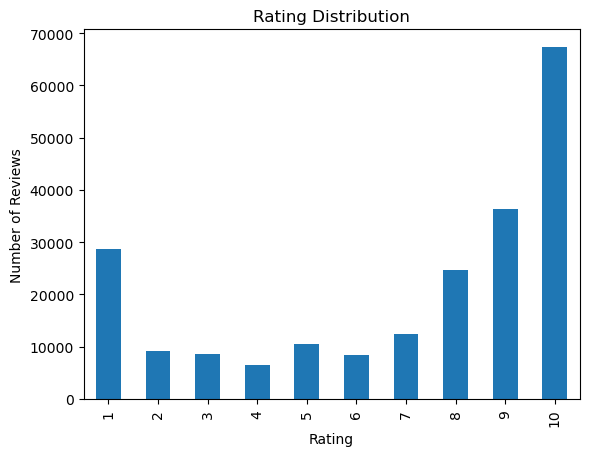

In [15]:
import matplotlib.pyplot as plt

rating_distribution = df["rating"].value_counts().sort_index()

rating_distribution.plot(kind="bar")

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")
plt.show()

In [16]:
drug_rating = df.groupby("drugName")["rating"].mean().sort_values(ascending=False)

In [17]:
drug_rating.head(10)

drugName
A + D Cracked Skin Relief      10.0
Goody's Headache Powders       10.0
Gilotrif                       10.0
Ginger                         10.0
Glecaprevir / pibrentasvir     10.0
Glimepiride / pioglitazone     10.0
Glimepiride / rosiglitazone    10.0
Glucosamine                    10.0
Glumetza                       10.0
Glyset                         10.0
Name: rating, dtype: float64

In [18]:
drug_sum = (df.groupby("drugName").agg(avg_rating=("rating", "mean"), reviews_count = ("rating", "count")).reset_index())
#Group by drug name. For each group, make me TWO columns — the average rating and the number of ratings. Then filter to only drugs with at least 50 reviews.
good_drugs = drug_sum[drug_sum["reviews_count"] >= 50]
good_drugs.sort_values("avg_rating", ascending=False).head(10)

,drugName,avg_rating,reviews_count
976,Dexbrompheniramine / pseudoephedrine,9.941176,51
787,Cobicistat / elvitegravir / emtricitabine / te...,9.460526,76
3087,Stribild,9.460526,76
936,Demerol,9.280702,57
765,Clobetasol,9.270588,85
1880,Librium,9.262626,99
3043,Soma,9.201439,139
2055,Meperidine,9.196970,66
3093,Subutex,9.189873,79
695,Chlorpheniramine / hydrocodone,9.188119,101


in the first top ten, there is probably something wrong with it when A + D Cracked Skin Relief   is the top and everything has perfect score. so i based o nthe averating of each product. and then only count something > 50 because, if there is one product has one 10 ratings, its is still the top. 

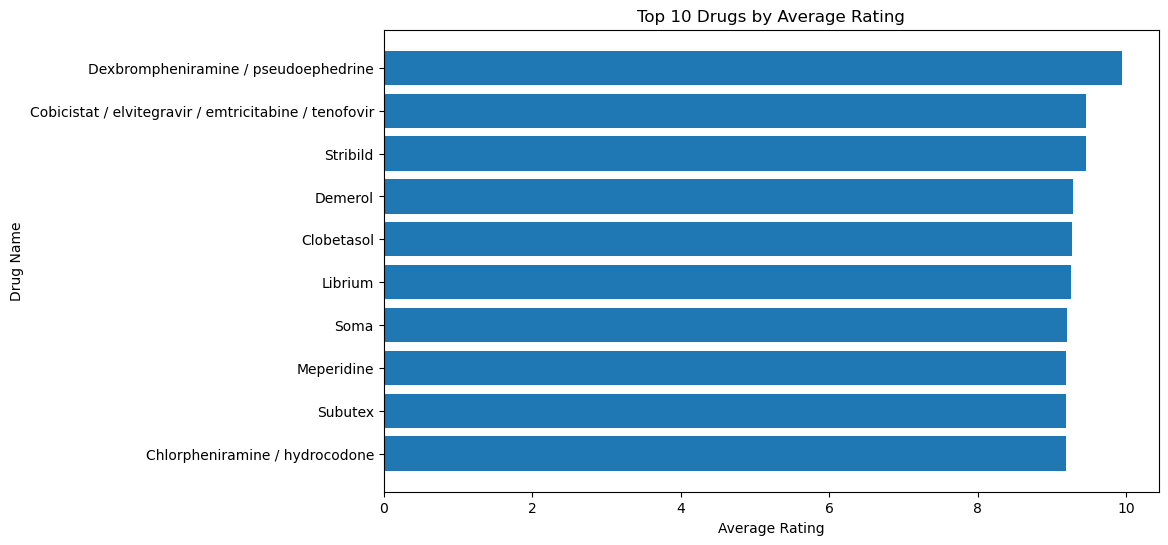

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

drug_sum = (
    df.groupby("drugName")
    .agg(
        avg_rating=("rating", "mean"),
        reviews_count=("rating", "count")
    )
    .reset_index()
)

good_drugs = drug_sum[drug_sum["reviews_count"] >= 50]

top_10_drugs = (
    good_drugs
    .sort_values("avg_rating", ascending=False)
    .head(10)
)
plt.figure(figsize=(10, 6))
plt.barh(top_10_drugs["drugName"], top_10_drugs["avg_rating"])
plt.xlabel("Average Rating")
plt.ylabel("Drug Name")
plt.title("Top 10 Drugs by Average Rating")
plt.gca().invert_yaxis()
plt.show()

In [20]:
print('rows               :', len(df))
print('null in condition  :', df['condition'].isna().sum())
print('null in drugName   :', df['drugName'].isna().sum())
print('sample pair        :', next(iter(zip(df['condition'].head(1), df['drugName'].head(1)))))

rows               : 212698
null in condition  : 0
null in drugName   : 0
sample pair        : ('Left Ventricular Dysfunction', 'Valsartan')


In [21]:
# building recommendation system with TruncatedSVD (matrix factorization)
# Same idea as before: map each condition -> row id and each drug -> column id.

condition_to_id = {c: i for i, c in enumerate(df['condition'].unique())}
drug_to_id      = {d: i for i, d in enumerate(df['drugName'].unique())}
id_to_drug      = {i: d for d, i in drug_to_id.items()}

n_conditions = len(condition_to_id)
n_drugs      = len(drug_to_id)
print('conditions :', n_conditions, '| drugs :', n_drugs)

conditions : 836 | drugs : 3654


#note: never use iterrrow- it slow. use zip, apply . lightfm count the gradient update, so we dont need to worry about the edge case above 

In [22]:
# Build the sparse interaction matrix (conditions x drugs).
# Each (condition, drug) review adds 1 to that cell, so a cell value = how many
# reviews link that condition to that drug. No .astype(str) — df is already cleaned
# (safety check confirmed 0 nulls), so we want this to error loud if df is dirty.

rows = df['condition'].map(condition_to_id).to_numpy()
cols = df['drugName'].map(drug_to_id).to_numpy()
vals = np.ones(len(df))

interactions = coo_matrix((vals, (rows, cols)), shape=(n_conditions, n_drugs)).tocsr()
print('matrix shape :', interactions.shape)
print('filled cells :', interactions.nnz)

matrix shape : (836, 3654)
filled cells : 8586


In [23]:
# Training the model with TruncatedSVD.
# n_components=30 latent factors (same as the 30 components we used before).
# fit_transform gives the condition (row) factors; model.components_ gives the drug factors.

model = TruncatedSVD(n_components=30, random_state=42)
condition_factors = model.fit_transform(interactions)   # (n_conditions, 30)
drug_factors      = model.components_.T                  # (n_drugs, 30)
print('training done')

training done


In [24]:
import numpy as np

def recommend(condition, top_n=10):
    if condition not in condition_to_id:
        return f"'{condition}' not found in dataset"
    cid = condition_to_id[condition]
    # score every drug = dot product of this condition's factors with each drug's factors
    scores = condition_factors[cid] @ drug_factors.T
    top_ids = np.argsort(-scores)[:top_n]
    return [id_to_drug[i] for i in top_ids]

print('Anxiety   :', recommend('Anxiety'))
print('Depression:', recommend('Depression'))
print('Acne      :', recommend('Acne'))

Anxiety   : ['Escitalopram', 'Alprazolam', 'Clonazepam', 'Buspirone', 'Lexapro', 'Lorazepam', 'Hydroxyzine', 'Xanax', 'BuSpar', 'Klonopin']
Depression: ['Bupropion', 'Sertraline', 'Venlafaxine', 'Desvenlafaxine', 'Pristiq', 'Escitalopram', 'Citalopram', 'Vortioxetine', 'Duloxetine', 'Lexapro']
Acne      : ['Isotretinoin', 'Adapalene / benzoyl peroxide', 'Doxycycline', 'Epiduo', 'Accutane', 'Benzoyl peroxide / clindamycin', 'Minocycline', 'Tretinoin', 'Ethinyl estradiol / norgestimate', 'Drospirenone / ethinyl estradiol']


# Part 2: 


In [26]:
# saved a copy for later. 
df.to_csv


<bound method NDFrame.to_csv of         uniqueID                  drugName                     condition  \
0         206461                 Valsartan  Left Ventricular Dysfunction   
1          95260                Guanfacine                          ADHD   
2          92703                    Lybrel                 Birth Control   
3         138000                Ortho Evra                 Birth Control   
4          35696  Buprenorphine / naloxone             Opiate Dependence   
...          ...                       ...                           ...   
212693    159999                 Tamoxifen     Breast Cancer, Prevention   
212694    140714              Escitalopram                       Anxiety   
212695    130945            Levonorgestrel                 Birth Control   
212696     47656                Tapentadol                          Pain   
212697    113712                 Arthrotec                      Sciatica   

                                                   revi

In [27]:
print('saved', df.shape)

saved (212698, 7)


In [ ]:
#using group by like SQL
# now we are going to Phase 1 — Build a drug_stats table: one row per (condition, drug) with avg rating + review count
from scipy import stats

stats = (
    df.groupby(['condition', 'drugName'])
      .agg(
          avg_rating=('rating', 'mean'),
          reviews_count=('rating', 'count'),
          avg_useful=('usefulCount', 'mean'),
      )
      .reset_index()
)
stats.head(100)

,condition,drugName,avg_rating,reviews_count,avg_useful
0,ADHD,Adderall,8.224670,227,44.004405
1,ADHD,Adderall XR,8.266187,139,29.402878
2,ADHD,Adzenys XR-ODT,5.952381,21,8.571429
3,ADHD,Amantadine,8.666667,3,15.666667
4,ADHD,Amphetamine,6.518519,54,9.333333
...,...,...,...,...,...
95,Abnormal Uterine Bleeding,Levlen,7.500000,4,5.250000
96,Abnormal Uterine Bleeding,Levonorgestrel,5.264789,355,13.929577
97,Abnormal Uterine Bleeding,Levora,5.000000,6,3.833333
98,Abnormal Uterine Bleeding,Lo / Ovral-28,10.000000,1,9.000000


In [45]:
C = df['rating'].mean()   # global average rating (the anchor)
m = 25
v = stats['reviews_count']
R = stats['avg_rating']

stats['score'] = (v / (v + m)) * R + (m / (v + m)) * C
stats = stats.sort_values(['condition', 'score'], ascending=[True, False])
stats.head()

,condition,drugName,avg_rating,reviews_count,avg_useful,score
21,ADHD,Dextroamphetamine,8.712766,94,33.319149,8.351351
17,ADHD,Desoxyn,9.631579,19,81.578947,8.132063
0,ADHD,Adderall,8.224670,227,44.004405,8.102424
1,ADHD,Adderall XR,8.266187,139,29.402878,8.072017
19,ADHD,Dexedrine,8.421053,57,46.035088,7.985497


In [46]:
#test:

In [47]:
stats[stats['condition'] == 'Depression'].head(10)[
    ['drugName', 'avg_rating', 'reviews_count', 'score']
]


,drugName,avg_rating,reviews_count,score
2560,Tramadol,9.413333,75,8.808108
2466,Alprazolam,9.146341,82,8.643091
2575,Xanax,9.171875,64,8.559672
2531,Parnate,8.913043,46,8.236771
2522,Niacin,9.750000,20,8.218017
2517,Methylphenidate,9.000000,32,8.119487
2556,St. john's wort,8.666667,51,8.115931
2561,Tranylcypromine,8.518519,54,8.035579
2467,Amitriptyline,8.490196,51,7.997510
2521,Nefazodone,8.869565,23,7.891891


In [48]:
print(recommend('ADHD'))
print(recommend('Anxiety'))
print(recommend('High Blood Pressure'))

['Lisdexamfetamine', 'Vyvanse', 'Methylphenidate', 'Amphetamine / dextroamphetamine', 'Atomoxetine', 'Strattera', 'Concerta', 'Adderall', 'Guanfacine', 'Adderall XR']
['Escitalopram', 'Alprazolam', 'Clonazepam', 'Buspirone', 'Lexapro', 'Lorazepam', 'Hydroxyzine', 'Xanax', 'BuSpar', 'Klonopin']
['Lisinopril', 'Losartan', 'Amlodipine', 'Nebivolol', 'Bystolic', 'Metoprolol', 'Olmesartan', 'Hydrochlorothiazide', 'Atenolol', 'Valsartan']


In [50]:
def recommend(condition, top_n=5):
    # keep only rows for this condition
    rows = stats[stats['condition'] == condition]
    # best score first, take the top N
    rows = rows.sort_values('score', ascending=False).head(top_n)
    # return just the useful columns
    return rows[['drugName', 'avg_rating', 'reviews_count', 'score']].reset_index(drop=True)


recommend('ADHD')

,drugName,avg_rating,reviews_count,score
0,Dextroamphetamine,8.712766,94,8.351351
1,Desoxyn,9.631579,19,8.132063
2,Adderall,8.224670,227,8.102424
3,Adderall XR,8.266187,139,8.072017
4,Dexedrine,8.421053,57,7.985497


In [76]:

from rapidfuzz import process, fuzz

In [70]:
conditions = sorted(stats['condition'].unique())
print(len(conditions), 'conditions')
print(conditions[:20])

836 conditions
['ADHD', 'AIDS Related Wasting', 'AV Heart Block', 'Abdominal Distension', 'Abnormal Uterine Bleeding', 'Abortion', 'Acetaminophen Overdose', 'Acne', 'Actinic Keratosis', 'Acute Coronary Syndrome', 'Acute Lymphoblastic Leukemia', 'Acute Nonlymphocytic Leukemia', 'Acute Otitis Externa', 'Acute Promyelocytic Leukemia', "Addison's Disease", 'Adrenocortical Insufficiency', 'Adult Human Growth Hormone Deficiency', 'Aggressive Behavi', 'Agitated State', 'Agitation']


In [71]:

print(match_condition('headache'))
print(match_condition('high blood pressure'))
print(match_condition('cant sleep'))
print(match_condition('adhd'))


['Headache', 'New Daily Persistent Headache', 'Cluster Headaches']
['High Blood Pressure']
['eve']
['Bladder Infection', 'Gallbladder Disease', 'Overactive Bladde']


In [72]:
print(match_condition('adhd'))      
print(match_condition('headache'))
print(match_condition('high blood pressure'))
print(match_condition('cant sleep'))

['Bladder Infection', 'Gallbladder Disease', 'Overactive Bladde']
['Headache', 'New Daily Persistent Headache', 'Cluster Headaches']
['High Blood Pressure']
['eve']


In [73]:
from rapidfuzz import process, fuzz, utils
process.extract('adhd', conditions,
                scorer=fuzz.WRatio,
                processor=utils.default_process,
                limit=5)

[('ADHD', 100.0, 0),
 ("Addison's Disease", 77.14285714285715, 14),
 ('Bladder Infection', 67.5, 96),
 ('Gallbladder Disease', 67.5, 257),
 ('Overactive Bladde', 67.5, 530)]

In [74]:
print(match_condition('adhd'))      

['Bladder Infection', 'Gallbladder Disease', 'Overactive Bladde']


In [ ]:
from rapidfuzz import process, fuzz, utils

def match_condition(text, limit=3, cutoff=60):
    hits = process.extract(text, conditions,
                           scorer=fuzz.WRatio,
                           processor=utils.default_process,   # <-- must be here
                           limit=limit)
    return [name for name, score, _ in hits if score >= cutoff]

print(match_condition('adhd'))  

['ADHD', "Addison's Disease", 'Bladder Infection']


In [77]:
df.to_csv('../data/clean_reviews.csv', index=False)

In [78]:
import os
print(os.path.exists('../data/clean_reviews.csv'))

True
